<a href="https://colab.research.google.com/github/dorhoffman/SWINGPULSE/blob/main/notebooks/01_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import glob
import pandas as pd

csv_files = glob.glob("/content/**/*.csv", recursive=True)

print(f"Found {len(csv_files)} CSV files")

Found 507 CSV files


In [3]:
output_file = "/content/SWINGPULSE_MASTER_DATASET.csv"

# אם כבר קיים קובץ מהרצה קודמת - נמחק אותו
if os.path.exists(output_file):
    os.remove(output_file)

first_file = True
failed_files = []

for index, file_path in enumerate(csv_files, start=1):
    try:
        df = pd.read_csv(file_path)

        ticker = os.path.splitext(
            os.path.basename(file_path)
        )[0]

        df["Symbol"] = ticker

        df.to_csv(
            output_file,
            mode="w" if first_file else "a",
            header=first_file,
            index=False
        )

        first_file = False

        if index % 25 == 0:
            print(f"Processed {index}/{len(csv_files)} files")

        del df

    except Exception as error:
        failed_files.append((file_path, str(error)))

print("Merge completed")
print("Failed files:", len(failed_files))

Processed 25/507 files
Processed 50/507 files
Processed 75/507 files
Processed 100/507 files
Processed 125/507 files
Processed 150/507 files
Processed 175/507 files
Processed 200/507 files
Processed 225/507 files
Processed 250/507 files
Processed 275/507 files
Processed 300/507 files
Processed 325/507 files
Processed 350/507 files
Processed 375/507 files
Processed 400/507 files
Processed 425/507 files
Processed 450/507 files
Processed 475/507 files
Processed 500/507 files
Merge completed
Failed files: 0


In [4]:
sample = pd.read_csv(
    output_file,
    nrows=10
)

display(sample)
print(sample.columns.tolist())

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Symbol
0,2014-09-22 00:00:00-04:00,4.75,4.75,4.10,4.35,21900,0.0,0.0,CZR
1,2014-09-23 00:00:00-04:00,4.45,4.45,3.90,4.26,81700,0.0,0.0,CZR
2,2014-09-24 00:00:00-04:00,3.70,4.34,3.61,4.34,94400,0.0,0.0,CZR
3,2014-09-25 00:00:00-04:00,4.35,4.44,3.80,4.00,29800,0.0,0.0,CZR
4,2014-09-26 00:00:00-04:00,4.00,4.40,4.00,4.40,161500,0.0,0.0,CZR
5,2014-09-29 00:00:00-04:00,4.39,4.39,4.00,4.23,138700,0.0,0.0,CZR
6,2014-09-30 00:00:00-04:00,4.14,4.25,4.00,4.21,26100,0.0,0.0,CZR
7,2014-10-01 00:00:00-04:00,4.21,4.21,4.03,4.10,105900,0.0,0.0,CZR
8,2014-10-02 00:00:00-04:00,4.08,4.27,3.74,4.27,32500,0.0,0.0,CZR
9,2014-10-03 00:00:00-04:00,4.00,4.29,3.91,4.15,38300,0.0,0.0,CZR


['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Symbol']


In [5]:
total_rows = 0

for chunk in pd.read_csv(
    output_file,
    chunksize=100_000
):
    total_rows += len(chunk)

print(f"Total rows: {total_rows:,}")

ParserError: Error tokenizing data. C error: Expected 9 fields in line 4208049, saw 786


In [6]:
import os

output_file = "/content/SWINGPULSE_MASTER_DATASET.csv"

if os.path.exists(output_file):
    os.remove(output_file)
    print("הקובץ הפגום נמחק")
else:
    print("לא נמצא קובץ קודם")

הקובץ הפגום נמחק


In [7]:
import glob

csv_files = glob.glob("/content/**/*.csv", recursive=True)

csv_files = [
    file_path
    for file_path in csv_files
    if os.path.abspath(file_path) != os.path.abspath(output_file)
    and "SWINGPULSE_MASTER_DATASET" not in os.path.basename(file_path)
]

print("מספר קובצי מקור:", len(csv_files))
print(csv_files[:10])

מספר קובצי מקור: 507
['/content/CZR.csv', '/content/PNW.csv', '/content/D.csv', '/content/LOW.csv', '/content/AEE.csv', '/content/AON.csv', '/content/META.csv', '/content/SEE.csv', '/content/DGX.csv', '/content/MMC.csv']


In [8]:
import pandas as pd
import os

schemas = {}

for file_path in csv_files:
    try:
        columns = tuple(pd.read_csv(file_path, nrows=2).columns)
        schemas[columns] = schemas.get(columns, 0) + 1
    except Exception as error:
        print("בעיה בקריאת:", file_path, error)

for columns, count in schemas.items():
    print("\nמספר קבצים:", count)
    print("עמודות:", columns)


מספר קבצים: 503
עמודות: ('Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits')

מספר קבצים: 1
עמודות: ('6', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '0.14', '0.15', '0.16', '0.17', '0.18', '0.19', '0.20', '0.21', '0.22', '0.23', '0.24', '0.25', '0.26', '0.27', '0.28', '0.29', '0.30', '0.31', '0.32', '0.33', '0.34', '0.35', '0.36', '0.37', '0.38', '0.39', '0.40', '0.41', '0.42', '0.43', '0.44', '0.45', '0.46', '0.47', '0.48', '0.49', '0.50', '0.51', '0.52', '0.53', '0.54', '0.55', '0.56', '0.57', '0.58', '0.59', '0.60', '0.61', '0.62', '0.63', '0.64', '0.65', '0.66', '0.67', '0.68', '0.69', '0.70', '0.71', '0.72', '0.73', '0.74', '0.75', '0.76', '0.77', '0.78', '0.79', '0.80', '0.81', '0.82', '0.83', '0.84', '0.85', '0.86', '0.87', '0.88', '0.89', '0.90', '0.91', '0.92', '0.93', '0.94', '0.95', '0.96', '0.97', '0.98', '0.99', '0.100', '0.101', '0.102', '0.103', '0.104', '0.105', '0.106', '0.107', '0.108

In [9]:
import pandas as pd
import os

output_file = "/content/SWINGPULSE_MASTER_DATASET.csv"

if os.path.exists(output_file):
    os.remove(output_file)

required_mapping = {
    "date": "Date",
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "adj close": "Adj_Close",
    "adj_close": "Adj_Close",
    "volume": "Volume",
    "dividends": "Dividends",
    "stock splits": "Stock_Splits",
    "stock_splits": "Stock_Splits"
}

first_write = True
successful_files = 0
failed_files = []

for index, file_path in enumerate(csv_files, start=1):
    try:
        df = pd.read_csv(file_path)

        # ניקוי שמות העמודות
        df.columns = [
            str(column).strip()
            for column in df.columns
        ]

        rename_columns = {}

        for column in df.columns:
            normalized = column.lower().strip()
            if normalized in required_mapping:
                rename_columns[column] = required_mapping[normalized]

        df = df.rename(columns=rename_columns)

        essential_columns = [
            "Date",
            "Open",
            "High",
            "Low",
            "Close",
            "Volume"
        ]

        missing_columns = [
            column
            for column in essential_columns
            if column not in df.columns
        ]

        if missing_columns:
            raise ValueError(
                f"חסרות עמודות: {missing_columns}"
            )

        ticker = os.path.splitext(
            os.path.basename(file_path)
        )[0]

        df["Symbol"] = ticker

        selected_columns = [
            column
            for column in [
                "Date",
                "Symbol",
                "Open",
                "High",
                "Low",
                "Close",
                "Adj_Close",
                "Volume",
                "Dividends",
                "Stock_Splits"
            ]
            if column in df.columns
        ]

        df = df[selected_columns]

        df.to_csv(
            output_file,
            mode="w" if first_write else "a",
            header=first_write,
            index=False
        )

        first_write = False
        successful_files += 1

        if index % 25 == 0:
            print(
                f"עובדו {index}/{len(csv_files)} קבצים"
            )

        del df

    except Exception as error:
        failed_files.append(
            {
                "file": os.path.basename(file_path),
                "error": str(error)
            }
        )

print("\nהאיחוד הסתיים")
print("קבצים שהצליחו:", successful_files)
print("קבצים שנכשלו:", len(failed_files))

if failed_files:
    display(pd.DataFrame(failed_files).head(20))

עובדו 25/507 קבצים
עובדו 50/507 קבצים
עובדו 75/507 קבצים
עובדו 100/507 קבצים
עובדו 125/507 קבצים
עובדו 150/507 קבצים
עובדו 175/507 קבצים
עובדו 200/507 קבצים
עובדו 225/507 קבצים
עובדו 250/507 קבצים
עובדו 275/507 קבצים
עובדו 300/507 קבצים
עובדו 325/507 קבצים
עובדו 350/507 קבצים
עובדו 375/507 קבצים
עובדו 400/507 קבצים
עובדו 425/507 קבצים
עובדו 450/507 קבצים
עובדו 475/507 קבצים
עובדו 500/507 קבצים

האיחוד הסתיים
קבצים שהצליחו: 503
קבצים שנכשלו: 4


,file,error
0,mnist_train_small.csv,"חסרות עמודות: ['Date', 'Open', 'High', 'Low', ..."
1,california_housing_train.csv,"חסרות עמודות: ['Date', 'Open', 'High', 'Low', ..."
2,california_housing_test.csv,"חסרות עמודות: ['Date', 'Open', 'High', 'Low', ..."
3,mnist_test.csv,"חסרות עמודות: ['Date', 'Open', 'High', 'Low', ..."


In [10]:
sample = pd.read_csv(
    output_file,
    nrows=10
)

display(sample)
print(sample.columns.tolist())

,Date,Symbol,Open,High,Low,Close,Volume,Dividends,Stock_Splits
0,2014-09-22 00:00:00-04:00,CZR,4.75,4.75,4.10,4.35,21900,0.0,0.0
1,2014-09-23 00:00:00-04:00,CZR,4.45,4.45,3.90,4.26,81700,0.0,0.0
2,2014-09-24 00:00:00-04:00,CZR,3.70,4.34,3.61,4.34,94400,0.0,0.0
3,2014-09-25 00:00:00-04:00,CZR,4.35,4.44,3.80,4.00,29800,0.0,0.0
4,2014-09-26 00:00:00-04:00,CZR,4.00,4.40,4.00,4.40,161500,0.0,0.0
5,2014-09-29 00:00:00-04:00,CZR,4.39,4.39,4.00,4.23,138700,0.0,0.0
6,2014-09-30 00:00:00-04:00,CZR,4.14,4.25,4.00,4.21,26100,0.0,0.0
7,2014-10-01 00:00:00-04:00,CZR,4.21,4.21,4.03,4.10,105900,0.0,0.0
8,2014-10-02 00:00:00-04:00,CZR,4.08,4.27,3.74,4.27,32500,0.0,0.0
9,2014-10-03 00:00:00-04:00,CZR,4.00,4.29,3.91,4.15,38300,0.0,0.0


['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock_Splits']


In [11]:
total_rows = 0
symbols = set()

for chunk in pd.read_csv(
    output_file,
    chunksize=100_000
):
    total_rows += len(chunk)
    symbols.update(chunk["Symbol"].dropna().unique())

print(f"מספר רשומות: {total_rows:,}")
print(f"מספר מניות: {len(symbols):,}")

מספר רשומות: 4,208,047
מספר מניות: 503


In [12]:
stocks = pd.read_csv(
    "SWINGPULSE_MASTER_DATASET.csv"
)

print(stocks.shape)

stocks.head()

(4208047, 9)


,Date,Symbol,Open,High,Low,Close,Volume,Dividends,Stock_Splits
0,2014-09-22 00:00:00-04:00,CZR,4.75,4.75,4.10,4.35,21900,0.0,0.0
1,2014-09-23 00:00:00-04:00,CZR,4.45,4.45,3.90,4.26,81700,0.0,0.0
2,2014-09-24 00:00:00-04:00,CZR,3.70,4.34,3.61,4.34,94400,0.0,0.0
3,2014-09-25 00:00:00-04:00,CZR,4.35,4.44,3.80,4.00,29800,0.0,0.0
4,2014-09-26 00:00:00-04:00,CZR,4.00,4.40,4.00,4.40,161500,0.0,0.0


In [13]:
stocks.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4208047 entries, 0 to 4208046
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Date          object 
 1   Symbol        object 
 2   Open          float64
 3   High          float64
 4   Low           float64
 5   Close         float64
 6   Volume        int64  
 7   Dividends     float64
 8   Stock_Splits  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 288.9+ MB


In [14]:
stocks.isnull().sum()

,0
Date,0
Symbol,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock_Splits,0


In [15]:
stocks.duplicated().sum()

np.int64(0)

In [16]:
import pandas as pd
import numpy as np

stocks = pd.read_csv("SWINGPULSE_MASTER_DATASET.csv")

print(stocks.shape)
stocks.head()

(4208047, 9)


,Date,Symbol,Open,High,Low,Close,Volume,Dividends,Stock_Splits
0,2014-09-22 00:00:00-04:00,CZR,4.75,4.75,4.10,4.35,21900,0.0,0.0
1,2014-09-23 00:00:00-04:00,CZR,4.45,4.45,3.90,4.26,81700,0.0,0.0
2,2014-09-24 00:00:00-04:00,CZR,3.70,4.34,3.61,4.34,94400,0.0,0.0
3,2014-09-25 00:00:00-04:00,CZR,4.35,4.44,3.80,4.00,29800,0.0,0.0
4,2014-09-26 00:00:00-04:00,CZR,4.00,4.40,4.00,4.40,161500,0.0,0.0


In [17]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4208047 entries, 0 to 4208046
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Date          object 
 1   Symbol        object 
 2   Open          float64
 3   High          float64
 4   Low           float64
 5   Close         float64
 6   Volume        int64  
 7   Dividends     float64
 8   Stock_Splits  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 288.9+ MB


In [18]:
print("Missing Values")
print(stocks.isnull().sum())

print("\nDuplicates")
print(stocks.duplicated().sum())

Missing Values
Date            0
Symbol          0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock_Splits    0
dtype: int64

Duplicates
0


In [19]:
price_columns = ["Open", "High", "Low", "Close", "Volume"]

for column in price_columns:
    print(column, (stocks[column] < 0).sum())

Open 0
High 0
Low 0
Close 0
Volume 0


In [20]:
print(stocks["Symbol"].nunique())

503


In [21]:
stocks["Date"] = pd.to_datetime(stocks["Date"])

print(stocks["Date"].min())
print(stocks["Date"].max())

/tmp/ipykernel_2511/1984386326.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  stocks["Date"] = pd.to_datetime(stocks["Date"])


1962-01-02 00:00:00-05:00
2023-09-21 00:00:00-04:00


In [22]:
stocks_clean = stocks.copy()

In [23]:
stocks_clean.to_csv(
    "SWINGPULSE_CLEAN_DATASET.csv",
    index=False
)

In [24]:
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

print(f"Rows: {stocks_clean.shape[0]:,}")
print(f"Columns: {stocks_clean.shape[1]}")
print(f"Stocks: {stocks_clean['Symbol'].nunique()}")

DATASET INFORMATION
Rows: 4,208,047
Columns: 9
Stocks: 503


In [25]:
stocks_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4208047 entries, 0 to 4208046
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Date          object 
 1   Symbol        object 
 2   Open          float64
 3   High          float64
 4   Low           float64
 5   Close         float64
 6   Volume        int64  
 7   Dividends     float64
 8   Stock_Splits  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 288.9+ MB


In [26]:
missing = stocks_clean.isnull().sum()

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [27]:
duplicates = stocks_clean.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [28]:
price_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

for col in price_columns:

    print(col)

    print(
        (stocks_clean[col] < 0).sum()
    )

Open
0
High
0
Low
0
Close
0
Volume
0


In [29]:
invalid = stocks_clean[
    stocks_clean["High"] < stocks_clean["Low"]
]

print(len(invalid))

15


In [30]:
invalid

,Date,Symbol,Open,High,Low,Close,Volume,Dividends,Stock_Splits
459662,1968-02-20 00:00:00-05:00,XOM,0.0,0.167248,0.167554,0.169392,1030400,0.0,0.0
856957,1976-07-29 00:00:00-04:00,KR,0.0,0.050222,0.050363,0.049940,1436800,0.0,0.0
971601,1966-12-06 00:00:00-05:00,CVX,0.0,0.490273,0.491230,0.499848,396800,0.0,0.0
2287404,1968-09-23 00:00:00-04:00,MCD,0.0,0.199148,0.204150,0.204150,328050,0.0,0.0
2391933,1962-10-30 00:00:00-05:00,MO,0.0,0.001677,0.001749,0.001756,1382400,0.0,0.0
3220141,1963-03-28 00:00:00-05:00,MRO,0.0,0.452578,0.453724,0.450286,32011,0.0,0.0
3220142,1963-03-29 00:00:00-05:00,MRO,0.0,0.450286,0.454869,0.454869,22161,0.0,0.0
3221278,1967-10-02 00:00:00-04:00,MRO,0.0,0.825361,0.829467,0.825361,36211,0.0,0.0
3505496,1962-06-29 00:00:00-04:00,IP,0.0,0.678663,0.685066,0.665858,104851,0.0,0.0
3506542,1966-08-24 00:00:00-04:00,IP,0.0,0.814275,0.821921,0.798983,106222,0.0,0.0


In [31]:
stocks_clean = stocks_clean[
    stocks_clean["High"] >= stocks_clean["Low"]
]

In [32]:
print("="*50)
print("SWINGPULSE DATASET SUMMARY")
print("="*50)

print(f"Total rows: {len(stocks_clean):,}")
print(f"Total stocks: {stocks_clean['Symbol'].nunique()}")
print(f"Columns: {len(stocks_clean.columns)}")

print("\nDate Range")
print(stocks_clean["Date"].min())
print(stocks_clean["Date"].max())

SWINGPULSE DATASET SUMMARY
Total rows: 4,208,032
Total stocks: 503
Columns: 9

Date Range
1962-01-02 00:00:00-05:00
2023-09-21 00:00:00-04:00


In [33]:
stock_counts = (
    stocks_clean
    .groupby("Symbol")
    .size()
    .sort_values(ascending=False)
)

stock_counts.head(20)

,0
Symbol,
JNJ,15537
KO,15537
HPQ,15537
IBM,15537
BA,15537
MSI,15537
MMM,15537
MRK,15537
CNP,15537


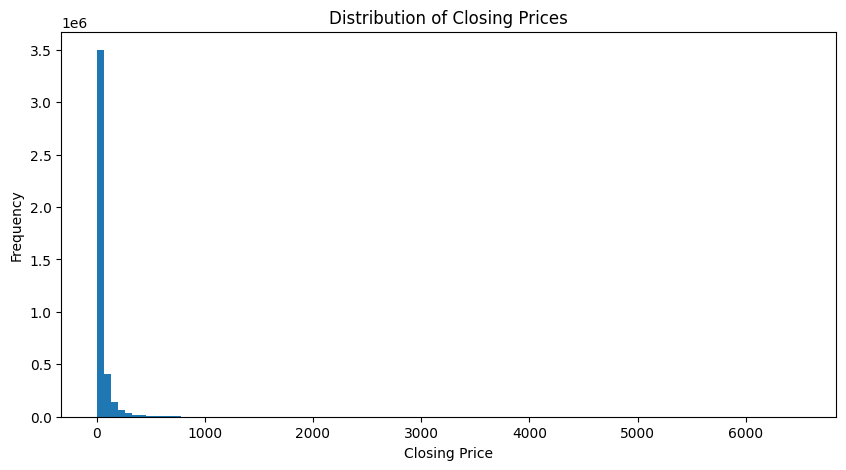

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    stocks_clean["Close"],
    bins=100
)

plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.show()

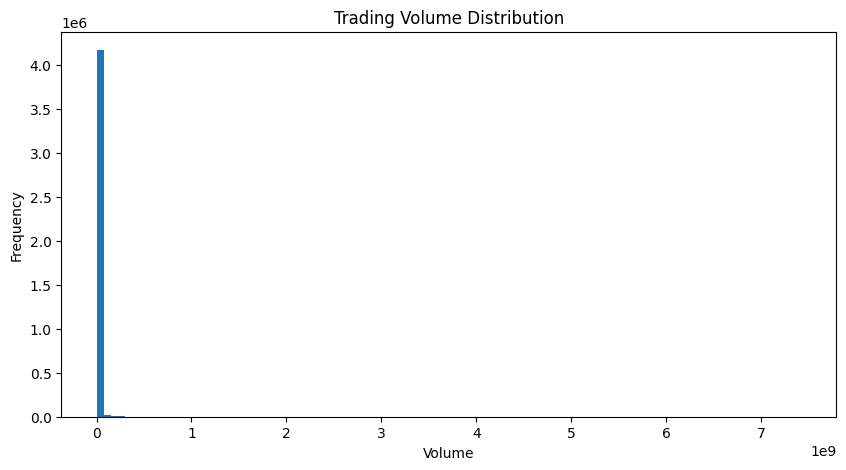

In [35]:
plt.figure(figsize=(10,5))

plt.hist(
    stocks_clean["Volume"],
    bins=100
)

plt.title("Trading Volume Distribution")
plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.show()

In [36]:
stocks_clean["Year"] = stocks_clean["Date"].dt.year

year_counts = (
    stocks_clean
    .groupby("Year")
    .size()
)

year_counts.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Records Per Year")
plt.ylabel("Number of Records")

plt.show()

AttributeError: Can only use .dt accessor with datetimelike values

In [37]:
stocks_clean["Date"] = pd.to_datetime(
    stocks_clean["Date"],
    errors="coerce"
)

In [38]:
stocks_clean["Year"] = stocks_clean["Date"].dt.year